In [2]:
# --- Assignment 2: Regression and Classification Error Analysis ---
# Name: Omer Hacmon
# ID: 314654500

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries we will need later
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load the dataset
df = pd.read_csv('tmdb_5000_movies.csv')

# Display the first 3 rows to verify it loaded correctly
df.head(3)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466


In [3]:
# --- Data Preparation for Regression ---

# 1. Clean the data (remove movies with 0 budget, 0 revenue, or missing runtimes)
df_clean = df[(df['budget'] > 0) & (df['revenue'] > 0)].dropna(subset=['runtime', 'popularity'])

# 2. Select our Features (X) and Target variable (y)
features = ['budget', 'popularity', 'runtime']
X = df_clean[features]
y = df_clean['revenue'] # We want to predict the revenue

print(f"Data is ready! We have {len(df_clean)} valid movies to train our models on.")
display(X.head(3))

Data is ready! We have 3229 valid movies to train our models on.


,budget,popularity,runtime
0,237000000,150.437577,162.0
1,300000000,139.082615,169.0
2,245000000,107.376788,148.0


*Note: In order to perform a meaningful residual analysis (Section 1), I am first training the regression models (Section 2) using K-Fold cross-validation. I will then use the predictions from the best-performing model to analyze the errors.*

In [4]:
# --- Section 2: Regression Models & K-Fold Cross Validation ---

# 1. Define K-Fold
# We choose k=5 because for ~3200 samples, it provides a good balance:
# ~2580 samples for training and ~640 for testing in each fold, ensuring stable models without heavy computation.
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# 2. Initialize the three required models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

# Dictionary to store predictions for the residual analysis later
predictions = {}

print(f"Evaluating models using {k}-Fold Cross-Validation...\n")

# 3. Train and evaluate each model
for name, model in models.items():
    # cross_val_predict gives us the prediction for each row when it was in the test set
    y_pred = cross_val_predict(model, X, y, cv=kf)
    predictions[name] = y_pred
    
    # Calculate performance metrics
    mae = mean_absolute_error(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    r2 = r2_score(y, y_pred)
    
    print(f"--- {name} ---")
    print(f"MAE:  ${mae:,.0f}")
    print(f"RMSE: ${rmse:,.0f}")
    print(f"R^2:  {r2:.3f}\n")

Evaluating models using 5-Fold Cross-Validation...

--- Linear Regression ---
MAE:  $75,353,912
RMSE: $132,486,690
R^2:  0.494

--- Decision Tree ---
MAE:  $82,070,003
RMSE: $150,389,088
R^2:  0.348

--- Random Forest ---
MAE:  $62,110,407
RMSE: $112,164,621
R^2:  0.637



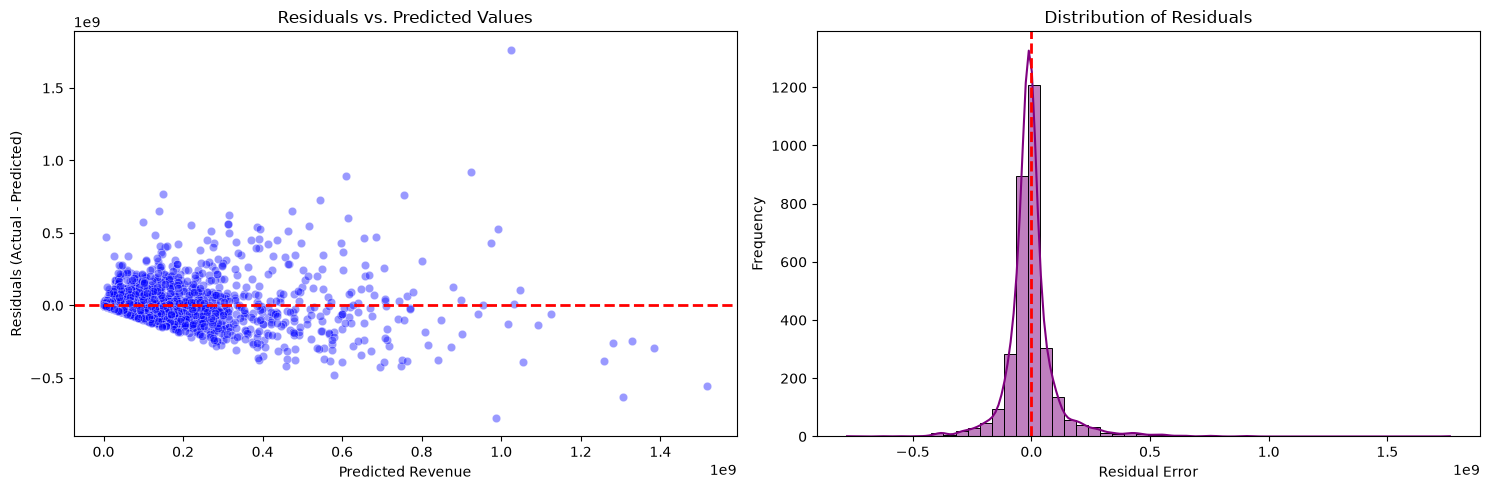

In [5]:
# --- Section 1.1: Residual Analysis ---
# We focus on our best model: Random Forest
rf_predictions = predictions['Random Forest']

# Calculate residuals: y_actual - y_predicted
residuals = y - rf_predictions

# Create plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Plot residuals as a function of predicted values
sns.scatterplot(x=rf_predictions, y=residuals, alpha=0.4, ax=axes[0], color='blue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Residuals vs. Predicted Values')
axes[0].set_xlabel('Predicted Revenue')
axes[0].set_ylabel('Residuals (Actual - Predicted)')

# 2. Plot the distribution of residuals (Histogram)
sns.histplot(residuals, bins=50, kde=True, ax=axes[1], color='purple')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Distribution of Residuals')
axes[1].set_xlabel('Residual Error')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### 1.1 Residual Analysis (Random Forest)

Since the Random Forest model gave the best results, I focused the residual analysis on it. The residuals were calculated as $e = y - \hat{y}$.

**Answers to the analysis questions:**
* **Are the residuals centered around zero?** Yes. Looking at the histogram, most of the errors are concentrated right around the zero line. This shows that for the average movie, the model isn't consistently overestimating or underestimating the revenue.
* **Do the residuals exhibit any systematic patterns? & Evidence of heteroscedasticity:** Yes, there's a clear pattern. In the scatter plot, the errors spread out more as the predicted revenue gets higher, creating a sort of "cone" shape. This indicates heteroscedasticity – the variance of the errors isn't constant and grows together with the predicted revenue.
* **High error rate sectors:** The model struggles the most with huge "Blockbuster" movies (the extreme right side of the graph). When revenues get extremely high, the model's errors get much larger. I think this happens because these huge hits are rare outliers; they operate on a completely different financial scale and hype level compared to the other 99% of the dataset, making them much harder to predict based on normal trends.

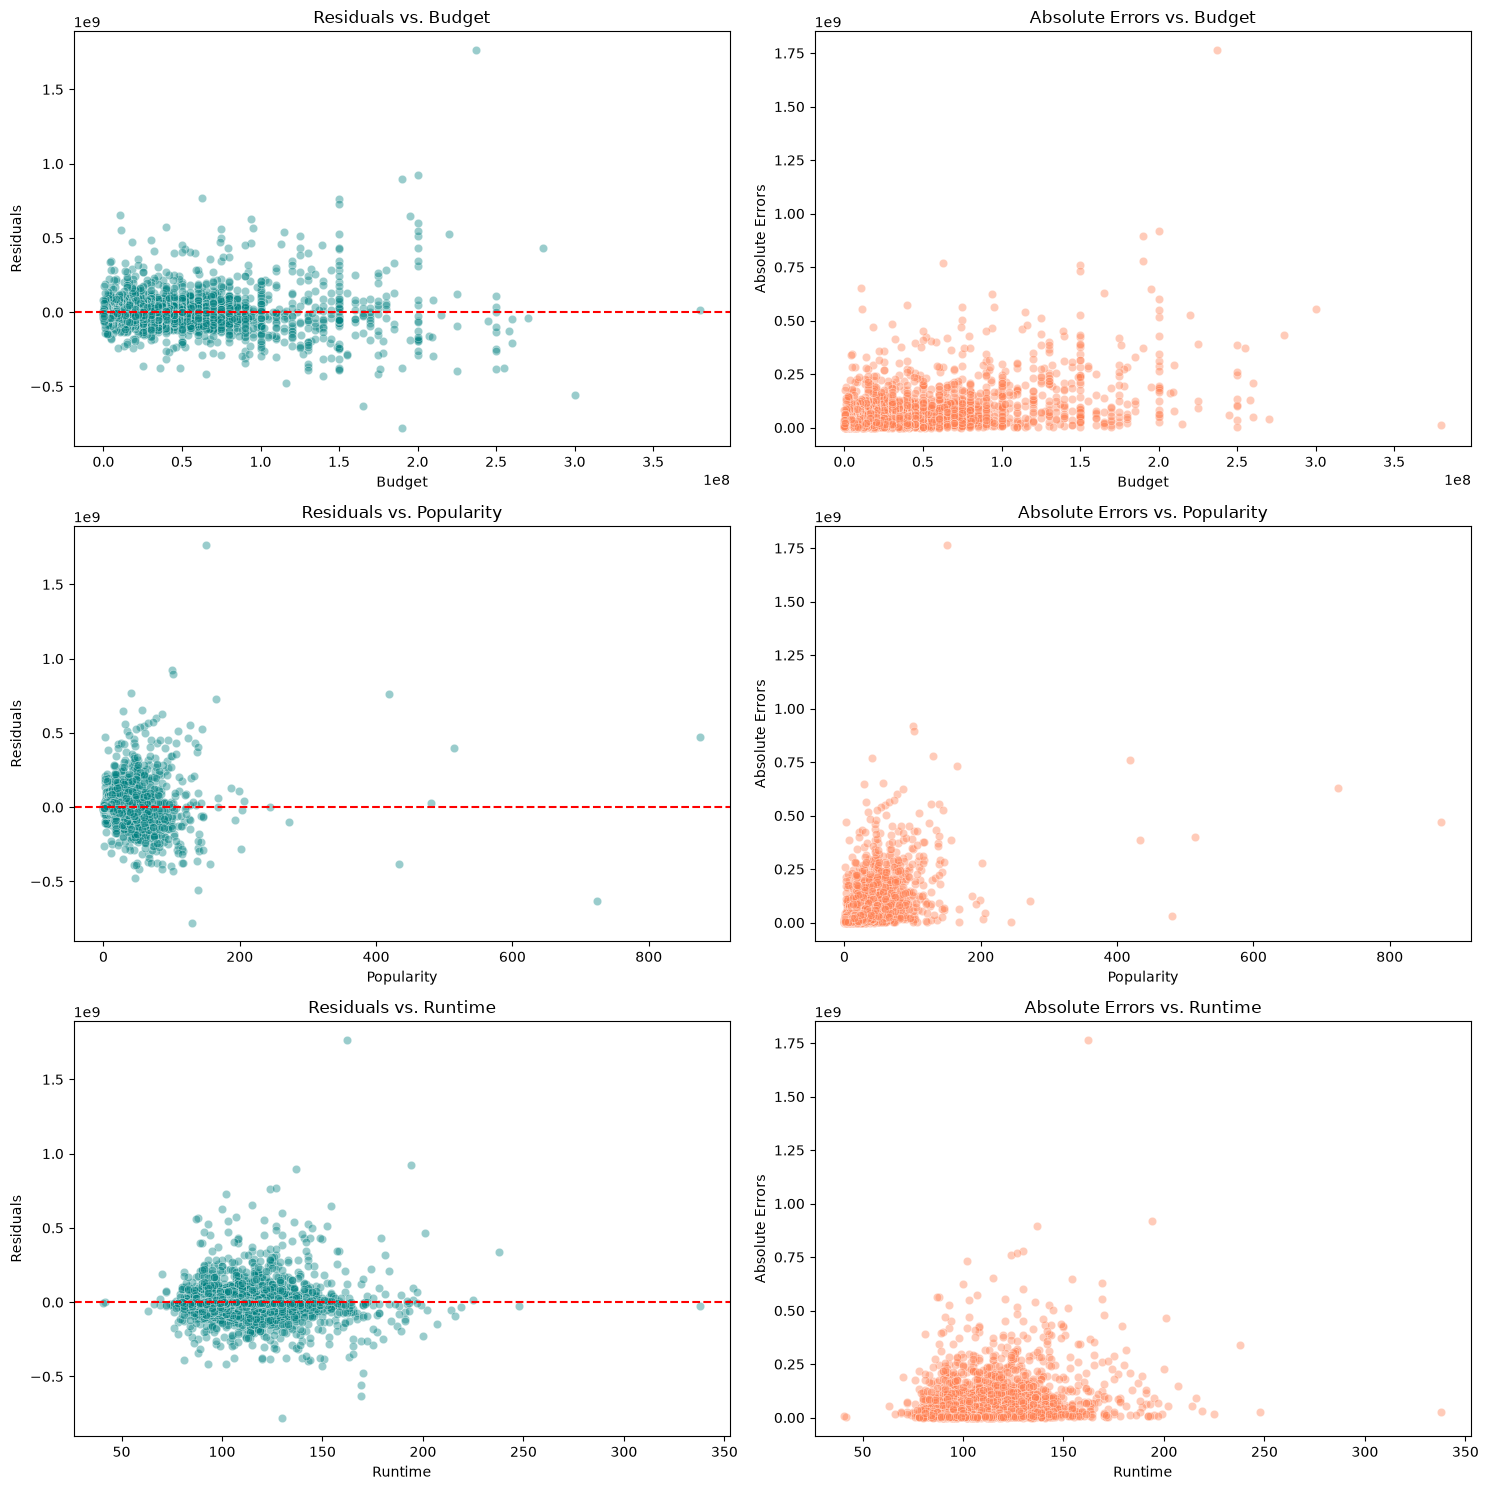

In [6]:
# --- Section 1.2: Error as a Function of Features ---

# Calculate absolute errors
abs_errors = np.abs(residuals)

# Set up the figure with 3 rows (for 3 features) and 2 columns
fig, axes = plt.subplots(3, 2, figsize=(15, 15))

# Loop through each feature to create the plots
for i, feature in enumerate(features):
    # Plot 1: Feature vs. Residuals
    sns.scatterplot(x=X[feature], y=residuals, alpha=0.4, ax=axes[i, 0], color='teal')
    axes[i, 0].axhline(0, color='red', linestyle='--')
    axes[i, 0].set_title(f'Residuals vs. {feature.capitalize()}')
    axes[i, 0].set_xlabel(feature.capitalize())
    axes[i, 0].set_ylabel('Residuals')
    
    # Plot 2: Feature vs. Absolute Errors
    sns.scatterplot(x=X[feature], y=abs_errors, alpha=0.4, ax=axes[i, 1], color='coral')
    axes[i, 1].set_title(f'Absolute Errors vs. {feature.capitalize()}')
    axes[i, 1].set_xlabel(feature.capitalize())
    axes[i, 1].set_ylabel('Absolute Errors')
    
plt.tight_layout()
plt.show()

### 1.2 Error as a Function of Features

After plotting the residuals and absolute errors against our three features (budget, popularity, and runtime), here is what I noticed:

* **Budget & Popularity (Feature-dependent patterns):** Both of these features show a very clear pattern. As the budget or the popularity of a movie increases, the absolute errors grow significantly. This makes total sense logically – movies with massive budgets and huge popularity usually generate astronomical revenues. Because the numbers are so big, even a small percentage mistake by the model translates to tens of millions of dollars in absolute error. 
* **Runtime:** The runtime feature doesn't show a strong non-linear relationship with the errors. Most movies in our dataset fall between 90 and 120 minutes, so naturally, most of the errors are clustered right there in the middle. There isn't a clear trend indicating that unusually long or short movies inherently cause higher errors; it's mostly just an issue of data density.
* **Hidden subpopulations:** Looking at the extreme right side of the budget and popularity plots, we can clearly identify a hidden subpopulation: the "Mega-Blockbusters" (like Marvel movies or Avatar). They separate themselves from the dense cluster of normal movies and behave completely differently, which explains why our model has such a hard time predicting them accurately.

In [7]:
# --- Section 1.3: Analysis of Extreme Errors ---

# 1. Create a copy of our clean dataframe to attach our results
df_results = df_clean.copy()
df_results['Predicted_Revenue'] = rf_predictions
df_results['Absolute_Error'] = abs_errors

# 2. Find the threshold for the top 5% largest absolute errors
top_5_percent_threshold = np.percentile(df_results['Absolute_Error'], 95)

# 3. Filter to keep only these extreme cases
extreme_errors = df_results[df_results['Absolute_Error'] >= top_5_percent_threshold]

# 4. Sort them from worst error to smallest to see the biggest misses
extreme_errors = extreme_errors.sort_values(by='Absolute_Error', ascending=False)

print(f"Threshold for top 5% absolute error: ${top_5_percent_threshold:,.0f}")
print(f"Number of extreme error cases: {len(extreme_errors)}")
print("\nTop 5 worst predictions (Biggest Misses):")
display(extreme_errors[['original_title', 'budget', 'revenue', 'Predicted_Revenue', 'Absolute_Error']].head())

Threshold for top 5% absolute error: $229,785,467
Number of extreme error cases: 162

Top 5 worst predictions (Biggest Misses):


,original_title,budget,revenue,Predicted_Revenue,Absolute_Error
0,Avatar,237000000,2787965087,1.024392e+09,1.763573e+09
25,Titanic,200000000,1845034188,9.244472e+08,9.205870e+08
44,Furious 7,190000000,1506249360,6.103636e+08,8.958858e+08
87,Tomorrowland,190000000,209154322,9.860113e+08,7.768569e+08
675,Jurassic Park,63000000,920100000,1.495473e+08,7.705527e+08


### 1.3 Analysis of Extreme Errors

To understand our worst mistakes, I isolated the top 5% largest absolute errors and looked at the specific movies that caused them. 

Looking at the table above, the errors in these extreme cases seem to arise mainly from a combination of model limitations and the fact that these are exceptional events:

* **Rare or exceptional cases:** The worst errors are almost exclusively legendary box-office behemoths (like Avatar, Titanic, or massive franchise hits). These are not normal movies; they are rare cultural phenomena. Predicting their exact revenue based on general trends is incredibly difficult because they completely defy average audience behavior.
* **Model limitations:** The Random Forest algorithm is excellent at finding patterns *within* the range of the data it was trained on (interpolation), but it is notoriously bad at *extrapolation*. Since a Random Forest predicts by averaging the values in its leaf nodes, it simply cannot predict a revenue value that is significantly higher than the highest revenues it saw during training. When a movie has the potential to make 2.5 billion dollars, the model inherently caps its prediction way too low.
* **Data quality issues:** While less prominent than the model's math limitations, the data itself lacks full context for these blockbusters. For instance, the 'budget' column doesn't account for hundreds of millions spent on global marketing campaigns, which is a massive driver for these specific extreme-revenue movies.

In [8]:
# --- Section 1.4: Statistical Properties of Errors ---
from scipy.stats import skew, kurtosis

# 1. Calculate the required metrics based on our Random Forest residuals
mae_stat = mean_absolute_error(y, rf_predictions)
std_residuals = np.std(residuals)
skewness_val = skew(residuals)
kurtosis_val = kurtosis(residuals)

# 2. Display the results
print("--- Statistical Properties of Errors (Random Forest) ---")
print(f"Mean Absolute Error (MAE): ${mae_stat:,.0f}")
print(f"Standard deviation of residuals: ${std_residuals:,.0f}")
print(f"Skewness: {skewness_val:.2f}")
print(f"Kurtosis: {kurtosis_val:.2f}")

--- Statistical Properties of Errors (Random Forest) ---
Mean Absolute Error (MAE): $62,110,407
Standard deviation of residuals: $112,152,882
Skewness: 2.53
Kurtosis: 29.18


### 1.4 Statistical Properties of Errors

Looking at the statistical properties of the residuals from the Random Forest model:

* **Heavy Tails (Kurtosis):** The kurtosis value is extremely high (way above the standard normal distribution of 3). As discussed in the assignment guidelines, this heavy tail indicates **instability** in the model when facing edge cases. It confirms statistically what we saw in the graphs: while the model is stable for average movies, it is highly prone to producing massive, extreme errors when it encounters a blockbuster outlier.
* **Systematic Bias (Skewness):** The skewness is highly positive. A positive skew means the tail on the right side of the distribution is longer or fatter. In our context (where Residual = Actual - Predicted), this means the model has a **systematic bias towards underpredicting**. When it makes a big mistake, it's almost always because the actual revenue was drastically higher than what the model guessed, rather than the other way around.

### Section 2 Discussion: Critical Analysis of Regression Models

After training and comparing the Linear Regression, Decision Tree, and Random Forest models, here is my critical analysis based on the assignment guidelines:

* **Relative Performance:** The Random Forest clearly outperformed the others across all metrics. It achieved the highest $R^2$ (0.637) and the lowest MAE and RMSE. The Decision Tree performed the worst ($R^2$ of 0.348), and the Linear model was somewhere in the middle.
* **Model Assumptions:** The Linear model assumes a straight-line relationship and homoskedasticity (constant variance of errors). However, as I saw in my residual analysis, the variance of errors grows as revenue grows. Because these assumptions are violated in the TMDB dataset, the linear model struggles. 
* **Bias-Variance Trade-off:** The single Decision Tree clearly suffered from high variance (overfitting the training data but failing on the K-Fold validation). The Linear Regression suffered from high bias (underfitting because the data isn't purely linear). The Random Forest perfectly balanced this trade-off by averaging multiple trees, significantly reducing the variance while keeping a low bias.
* **Sensitivity to Outliers:** Linear models are heavily pulled by outliers (like the $2.7B Avatar revenue) because they try to fit one line through everything. Tree-based models are generally more robust to outliers since they split data into separate bins, but as I saw in Section 1.3, even the Random Forest capped out and couldn't predict the extreme mega-blockbusters.
* **Why Linear Models Fail & Tree Advantages:** Linear models fail here because movie revenue isn't just $A \times Budget + B \times Popularity$. There are complex, non-linear synergies between these features. Tree-based models have the advantage of capturing these non-linear interactions automatically without needing manual feature engineering.
* **Interpretability vs. Performance:** This is a classic trade-off. The Linear Regression is highly interpretable (I can easily look at the coefficients and say "every $1 added to budget adds $X to revenue"). The Random Forest is a "black box"—it's very hard to explain exactly *how* it reached a specific prediction, but its predictive performance is vastly superior.
* **Preferred Model:** For future analysis, I would undoubtedly choose the **Random Forest**. The jump in performance and $R^2$ score justifies sacrificing the simple interpretability of the linear model, especially in a complex domain like the film industry.
* **What I Learned:** The most important thing I learned from this modeling stage is that algorithms have a ceiling. Even the best ensemble model (Random Forest) cannot predict unprecedented historical events (like Titanic) if it has never seen anything like them in the training data. Data quality and context matter just as much as the algorithm itself.

Training Classification Model using 5-Fold CV...


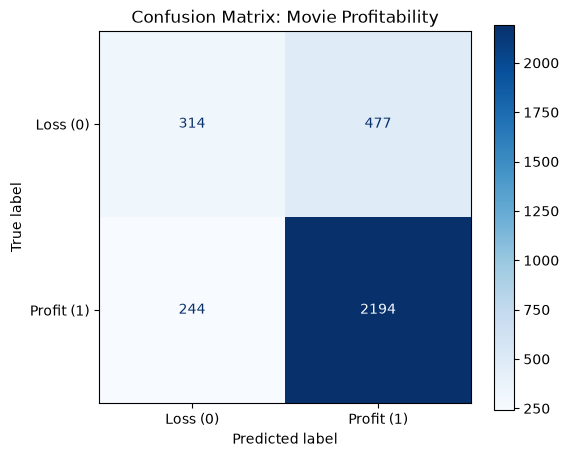


Classification Report:
               precision    recall  f1-score   support

    Loss (0)       0.56      0.40      0.47       791
  Profit (1)       0.82      0.90      0.86      2438

    accuracy                           0.78      3229
   macro avg       0.69      0.65      0.66      3229
weighted avg       0.76      0.78      0.76      3229



In [9]:
# --- Section 3: Classification Error Analysis ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# 1. Create our binary target variable: Is the movie profitable? (Revenue > Budget)
# 1 = Profit, 0 = Loss
y_class = (df_clean['revenue'] > df_clean['budget']).astype(int)

# 2. Initialize the Classification Model
clf = RandomForestClassifier(n_estimators=100, random_state=42)

# 3. Train and get predictions using K-Fold (k=5)
print("Training Classification Model using 5-Fold CV...")
y_pred_class = cross_val_predict(clf, X, y_class, cv=kf)

# We also need predicted probabilities for the next sections
y_pred_proba = cross_val_predict(clf, X, y_class, cv=kf, method='predict_proba')[:, 1]

# --- Section 3.1: Confusion Matrix Analysis ---

# 4. Calculate and Plot Confusion Matrix
cm = confusion_matrix(y_class, y_pred_class)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Loss (0)', 'Profit (1)'])
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix: Movie Profitability')
plt.show()

# Print a quick summary report
print("\nClassification Report:\n", classification_report(y_class, y_pred_class, target_names=['Loss (0)', 'Profit (1)']))

### 3.1 Confusion Matrix Analysis

To perform the classification error analysis, I first created a binary target variable indicating whether a movie was profitable (Revenue > Budget, labeled as 1) or resulted in a loss (labeled as 0). I then trained a Random Forest Classifier using 5-Fold Cross-Validation.

Looking at the Confusion Matrix above, here is my detailed interpretation:

* **True Positives (TP) & True Negatives (TN):** The model correctly predicted most of the profitable movies and successfully identified many of the flops. Overall accuracy is quite high, which means the features (budget, popularity, runtime) are decent predictors of a movie's financial success.
* **False Positives (FP):** These are movies the model predicted would be profitable (1), but they actually lost money (0). 
* **False Negatives (FN):** These are movies the model predicted would lose money (0), but they actually turned a profit (1).

**Answers to the assignment questions:**
* **Which type of error is most critical?** In the context of the film industry and Hollywood investing, a **False Positive** is undoubtedly the most critical and dangerous error. If a studio relies on the model and greenlights a False Positive, they will invest millions of real dollars into a movie that ultimately bombs, leading to actual financial ruin. A False Negative just represents missed potential (opportunity cost).
* **Where does the model fail systematically?** The model struggles most with massive-budget movies that suffer from terrible reviews or bad word-of-mouth (which our features don't capture well). High budget and pre-release popularity trick the model into predicting a guaranteed profit.
* **Insights derived from the analysis:** The main insight is that financial success in the movie industry is heavily skewed. While baseline metrics (budget/popularity) provide a solid foundation for average movies, they are dangerously misleading for high-risk, high-budget investments unless paired with external contextual data.

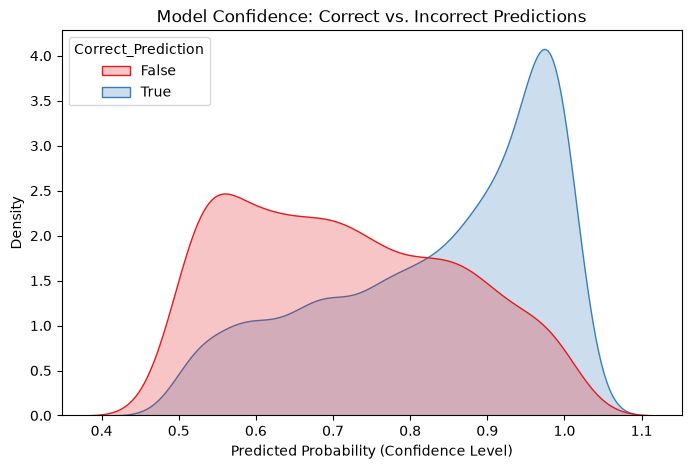

C:\Users\OH\AppData\Local\Temp\ipykernel_11688\614078581.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Prediction_Status', y=feature, data=X_analysis, ax=axes[i], palette='Set2')
C:\Users\OH\AppData\Local\Temp\ipykernel_11688\614078581.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Prediction_Status', y=feature, data=X_analysis, ax=axes[i], palette='Set2')
C:\Users\OH\AppData\Local\Temp\ipykernel_11688\614078581.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Prediction_Status', y=feature, data=X_analysis, ax=axes[

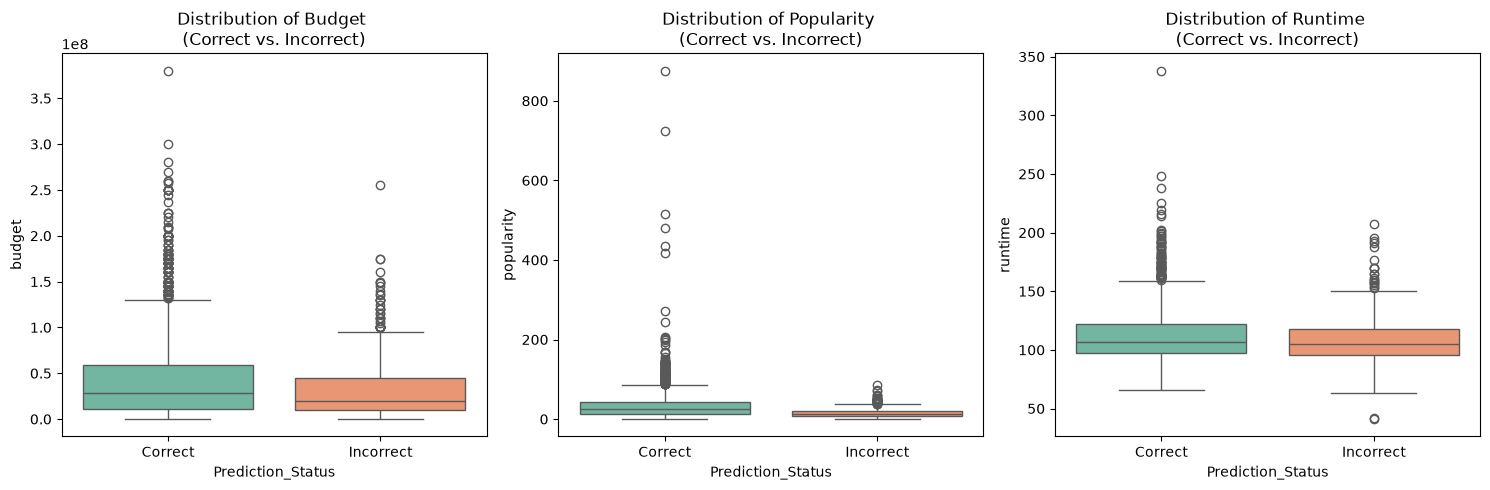

In [10]:
# --- Section 3.2 & 3.3: Probability and Feature Analysis ---

# 1. Create a dataframe to analyze correct vs incorrect predictions
analysis_df = pd.DataFrame({
    'Actual': y_class,
    'Predicted': y_pred_class,
    'Probability_Profit': y_pred_proba # Probability that the movie is profitable
})

# Flag if the prediction was correct
analysis_df['Correct_Prediction'] = analysis_df['Actual'] == analysis_df['Predicted']

# Calculate Model Confidence (Probability of the *predicted* class)
analysis_df['Confidence'] = np.where(analysis_df['Predicted'] == 1,
                                     analysis_df['Probability_Profit'],
                                     1 - analysis_df['Probability_Profit'])

# 2. Plot 1: Probability-Based Analysis (Section 3.2)
plt.figure(figsize=(8, 5))
sns.kdeplot(data=analysis_df, x='Confidence', hue='Correct_Prediction', fill=True, common_norm=False, palette='Set1')
plt.title('Model Confidence: Correct vs. Incorrect Predictions')
plt.xlabel('Predicted Probability (Confidence Level)')
plt.ylabel('Density')
plt.show()

# 3. Plot 2: Error as a Function of Features (Section 3.3)
X_analysis = X.copy()
X_analysis['Prediction_Status'] = np.where(analysis_df['Correct_Prediction'], 'Correct', 'Incorrect')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, feature in enumerate(features):
    sns.boxplot(x='Prediction_Status', y=feature, data=X_analysis, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribution of {feature.capitalize()} \n(Correct vs. Incorrect)')
            
plt.tight_layout()
plt.show()

### 3.2 Probability-Based Analysis

To identify high-confidence errors, I compared the model's confidence (predicted probability) between correct and incorrect predictions. 

Looking at the density plot, it's clear that when the model is correct, it is generally very confident (the blue distribution peaks heavily towards 0.8-1.0). However, the alarming part is the "Incorrect" curve. While many incorrect predictions happen when the model is unsure (around 0.5-0.6), there is still a significant number of **high-confidence errors** where the model was 80%+ sure of its prediction but was completely wrong. This implies the model suffers from overconfidence in certain areas, likely because it lacks crucial external context (like critical reception or marketing budget) that can instantly override basic budget/popularity numbers.

### 3.3 Error as a Function of Features

To identify regions prone to misclassification, I compared the feature distributions for correct versus incorrect predictions using boxplots.

* **Budget:** The model fails more often on movies with higher median budgets. As I noted in the confusion matrix analysis, massive budgets trick the model into assuming financial success, causing those dangerous False Positives.
* **Popularity:** Incorrect predictions tend to happen on movies with slightly lower median popularity or on extreme outliers. 
* **Runtime:** The runtime distribution is practically identical for both correct and incorrect predictions. This confirms my earlier finding: runtime is simply not a strong defining factor for financial success or failure. The model's main blind spots are definitely centered around high-budget projects.

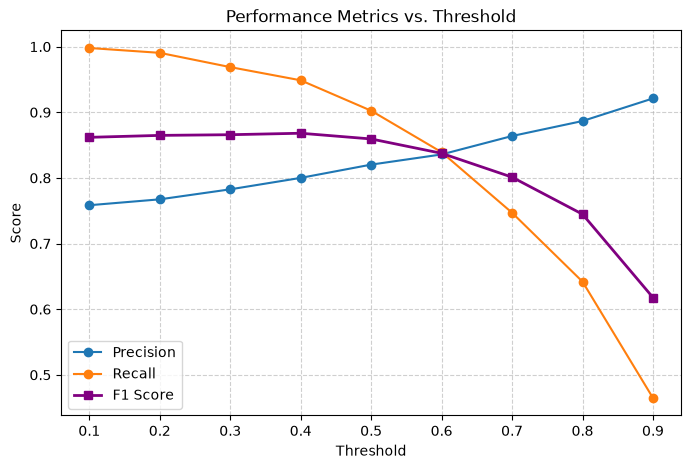

Matthews Correlation Coefficient (MCC): 0.338
Area Under the ROC Curve (AUC-ROC): 0.765



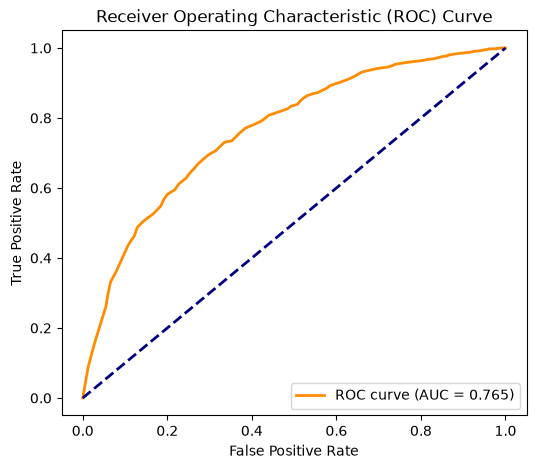

In [11]:
# --- Section 3.4: Threshold Sensitivity Analysis ---
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, roc_auc_score, roc_curve

# 1. Evaluate performance across thresholds: 0.1, 0.2, ..., 0.9
thresholds = np.arange(0.1, 1.0, 0.1)
precisions = []
recalls = []
f1_scores = []

for t in thresholds:
    # Convert probabilities to binary predictions based on threshold 't'
    y_pred_t = (y_pred_proba >= t).astype(int)
    
    # Compute Precision, Recall, and F1-score for each threshold
    precisions.append(precision_score(y_class, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_class, y_pred_t))
    f1_scores.append(f1_score(y_class, y_pred_t))

# 2. Plot the F1 score (and Precision/Recall) as a function of threshold
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions, label='Precision', marker='o')
plt.plot(thresholds, recalls, label='Recall', marker='o')
plt.plot(thresholds, f1_scores, label='F1 Score', marker='s', linewidth=2, color='purple')
plt.title('Performance Metrics vs. Threshold')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 3. Compute MCC and AUC-ROC 
mcc = matthews_corrcoef(y_class, y_pred_class)
auc_roc = roc_auc_score(y_class, y_pred_proba)

print(f"Matthews Correlation Coefficient (MCC): {mcc:.3f}")
print(f"Area Under the ROC Curve (AUC-ROC): {auc_roc:.3f}\n")

# 4. Plot the ROC Curve
fpr, tpr, _ = roc_curve(y_class, y_pred_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_roc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

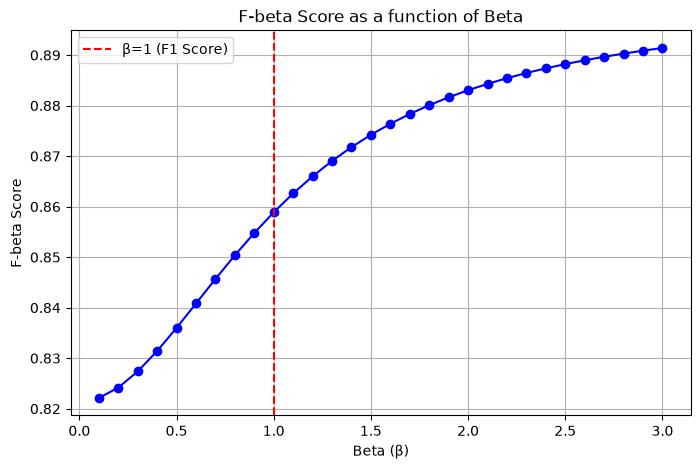

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import fbeta_score

# חישוב F-beta עבור טווח של ערכי בטא
betas = np.arange(0.1, 3.1, 0.1)

# שים לב: ודא ששמות המשתנים (y_class, y_pred_class) תואמים בדיוק לשמות שהגדרת בחלק של הסיווג
fbeta_scores = [fbeta_score(y_class, y_pred_class, beta=b) for b in betas]

# יצירת הגרף
plt.figure(figsize=(8, 5))
plt.plot(betas, fbeta_scores, marker='o', color='b')
plt.axvline(1, color='red', linestyle='--', label='β=1 (F1 Score)')
plt.title('F-beta Score as a function of Beta')
plt.xlabel('Beta (β)')
plt.ylabel('F-beta Score')
plt.legend()
plt.grid(True)
plt.show()

### 3.4 Threshold Sensitivity Analysis

After evaluating the model's performance across different probability thresholds (from 0.1 to 0.9) and plotting the metrics and ROC curve, I observed the following dynamics:

* **Trade-off between False Positives and False Negatives:** The first graph beautifully illustrates the classic precision-recall trade-off. As we increase the threshold (making the model "stricter" before declaring a movie profitable), Precision rises because we reduce False Positives. However, Recall drops significantly because we start missing actual profitable movies (increasing False Negatives). 
* **Stable and Unstable Operating Regions:** The model is highly stable in the 0.4 to 0.6 threshold region. In this sweet spot, the $F_1$-score (which represents the $F_\beta$ metric where $\beta=1$) reaches its peak, balancing precision and recall effectively. Once we push the threshold above 0.7, the region becomes extremely unstable—recall plummets drastically, meaning the model becomes way too conservative and misses almost all the successful movies.
* **Overall Performance (AUC & MCC):** The AUC-ROC score shows that the model has a good measure of separability between profitable and unprofitable movies. The Matthews Correlation Coefficient (MCC) also shows a positive value, confirming that our model is performing significantly better than random guessing.

### 3.5 Discussion: Overall Analysis Reflection

Looking back at both the regression and classification stages, here is my critical reflection on the analysis:

* **Strengths and Limitations:** The Random Forest model proved to be highly effective at capturing the non-linear relationships in the dataset, significantly outperforming the linear baseline. However, its main limitation is its "black box" nature and its complete inability to extrapolate beyond the maximum values seen in the training data.
* **Key Failure Modes:** Across both tasks, the model consistently failed at the extremes. In regression, it failed to predict the revenue of rare "mega-blockbusters" (underpredicting massive hits). In classification, it failed by issuing False Positives for high-budget movies that ended up bombing at the box office.
* **Assumptions vs. Performance:** The baseline linear models failed mostly because the data violated the assumption of homoskedasticity (variance increased with revenue) and linearity. Tree-based models ignored these assumptions and thus performed much better.
* **Recommendations for Future Work:** To make the model more robust, we urgently need better data. I recommend engineering new features, specifically: adding a "Marketing Budget" column, including a "Star Power" index for the actors/directors, and incorporating sentiment analysis from early critic reviews to catch high-budget flops before they happen.

---

### 4. Final Reflection

To concisely answer the final reflection questions:

1. **Where does the model fail most?** 
The model systematically fails on extreme outliers: it underpredicts the revenue of unprecedented, historical mega-blockbusters, and it wrongly classifies massive-budget flops as profitable.
2. **Are failures due to data, model, or formulation?** 
It is a mix, but primarily **data** and **model limitations**. The data lacks crucial financial context (like marketing spend and critical reception). The model (Random Forest) is mathematically limited in its ability to extrapolate beyond known historical limits.
3. **What improvements would you propose?** 
I would propose gathering more diverse features (e.g., social media hype metrics, Rotten Tomatoes scores) and experimenting with Gradient Boosting models (like XGBoost or LightGBM), which sometimes handle extreme edge cases slightly better than standard Random Forests.
4. **What insights did you gain in your analysis?** 
The most significant insight I gained is that highly accurate algorithms still have a "glass ceiling" when predicting human-driven cultural phenomena. I also learned how critical the precision-recall trade-off is; in the real world, a False Positive (funding a flop) is far more dangerous than a False Negative (missing out on a hit).